<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/iLogos/logo_novafct.png" width="200">

# Departamento de Engenharia Mecânica e Industrial
## Mecânica dos Sólidos II

## Tensões e deformações plásticas

### Problema 5

Considere a viga com a secção transversal em H indicada na figura e fabricada em aço com tensão de cedência $\sigma_C=$ 250 MPa. Determine:

**a)** O momento máximo elástico, $M_C$, o momento plástico, $M_P$, e o fator de forma, $K$, da secção em relação ao eixo $z$.

**b)** A distribuição de tensões residuais quando a secção é submetida a um momento com a intensidade $M_P$ e esse momento é em seguida retirado.


<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Au03/P5/MSII_Au03_P5.png"
width="400">

#### Dados do problema

In [2]:
import numpy as np
import sympy as sy
from sympy.solvers import solve
import matplotlib.pyplot as plt
import os

cor = '2'
if cor == '1':
    plt.rcParams['axes.facecolor'] = (.15, .15, .15)
    plt.rcParams['figure.facecolor'] = (.15, .15, .15)
    plt.rcParams['font.family'] = 'monospace'
    plt.rcParams['font.size'] = 18
    # plt.rcParams['text.usetex'] = True
    params = {"ytick.color" : (.8, .8, .8),
              "xtick.color" : (.8, .8, .8),
              "grid.color" : (.2, .2, .2),
              "text.color" : (.7, .7, .7),
              "axes.labelcolor" : (.8, .8, .8),
              "axes.edgecolor" : (.15, .15, .15)}
else:
    plt.rcParams['axes.facecolor'] = (.7, .7, .7)
    plt.rcParams['figure.facecolor'] = (.7, .7, .7)
    plt.rcParams['font.family'] = 'monospace'
    plt.rcParams['font.size'] = 18
    # plt.rcParams['text.usetex'] = True
    params = {"ytick.color" : (.1, .1, .1),
              "xtick.color" : (.1, .1, .1),
              "grid.color" : (.2, .2, .2),
              "text.color" : (.1, .1, .1),
              "axes.labelcolor" : (.1, .1, .1),
              "axes.edgecolor" : (.15, .15, .15)}
plt.rcParams.update(params)

# data structure, units: N, mm, MPa
# Create an empty class
class varin: pass

SigC = 250 # unit: MPa

S = varin()

S.l1 = 93.75 # mm
S.l2 = 12.5 # mm
S.lt = 2*S.l1 + S.l2
print(f'total length : {S.lt:.1f} [mm]')

S.h1 = 12.5 # mm
S.h2 = 225 # mm
S.ht = 2*S.h1 + S.h2
print(f'total width  : {S.ht:.1f} [mm]')

total length : 200.0 [mm]
total width  : 250.0 [mm]



# Resolução

## a) O momento máximo elástico, $M_C$, o momento plástico, $M_p$, e o fator de forma, $K$, da secção em relação ao eixo $z$.

### Propriedades de área de secção transversal

- Centróide da secção
Definido pela dupla simetria da geometria da secção.

- Momento de inércia de área

Cálculo recorrendo a tabelas e ao teorema dos eixos paralelos considrando sub-áreas retangulares elementares.

In [3]:
def iret(b,h): return b*h**3/12

I1 = iret(S.l2,S.h2)
print(f'I1 = {I1:.1f} [mm4]')

A2 = S.lt * S.h1
print(f'A2 = {A2:.1f} [mm2]')
d2 = (S.h1 + S.h2/2) - S.h1/2
print(f'd2 = {d2:.1f} [mm]')
I2 = iret(S.lt,S.h1) + A2*d2**2
print(f'I2 = {I2:.1f} [mm4]')

Iz = I1 + 2*I2
print(f'Iz = {Iz:.1f} [mm4]')

I1 = 11865234.4 [mm4]
A2 = 2500.0 [mm2]
d2 = 118.8 [mm]
I2 = 35286458.3 [mm4]
Iz = 82438151.0 [mm4]


#### Cálculo do momento fletor elástico máximo:

\begin{equation*}
\sigma_{xx} = -\frac{M_z}{I_z}y
\quad\therefore\quad
M_{C} = -\frac{\sigma_\mathrm{ced}I_z}{y_\mathrm{max}}
\end{equation*}

In [4]:
ymax = S.ht/2
print(f'ymax = {ymax:.1f} [mm]')

MzC = SigC*Iz/ymax
print(f'MzC = {MzC:.1f} [N.mm] = {MzC*1e-3*1e-3:.1f} [kN.m]')

ymax = 125.0 [mm]
MzC = 164876302.1 [N.mm] = 164.9 [kN.m]


- Momento plástico (assumindo a secção inteira completamente plástica)

1. Calcular a resultante das forças exercida pela distribuição da tensão normal de cedência sobre a sub-região.

\begin{equation*}
R_\textrm{banzo} = \sigma_\mathrm{ced} A_\textrm{banzo}
\quad\wedge\quad
R_\textrm{alma/2} = \sigma_\mathrm{ced} A_\textrm{alma/2}
\end{equation*}

2. Analisar o momento das forças resultantes em relação ao eixo neutro.

\begin{equation*}
M_\textrm{banzo} = R_\textrm{banzo}\cdot d_\textrm{centro-E.N.}
\quad\wedge\quad
M_\textrm{alma/2} = R_\textrm{alma/2}\cdot d_\textrm{centro-E.N.}
\end{equation*}

3. De notar que em plásticidade o eixo neutro passa sempre pelo centro da secção geométrica.

In [5]:
print(':: regiao do banzo ::')
Abanzo = S.lt*S.h1
print(f'Abanzo = {Abanzo:.1f} [mm2]')

Rbanzo = Abanzo*SigC
print(f'Rbanzo = {Rbanzo:.1f} [N]')

da = (S.h1 + S.h2/2) - S.h1/2
print(f'da     = {da:.1f} [mm]')
Mbanzo = Rbanzo*da
print(f'Mbanzo = {Mbanzo:.1f} [N.mm] = {Mbanzo*1e-3:.1f} [kN.m] ')

:: regiao do banzo ::
Abanzo = 2500.0 [mm2]
Rbanzo = 625000.0 [N]
da     = 118.8 [mm]
Mbanzo = 74218750.0 [N.mm] = 74218.8 [kN.m] 


In [12]:
print(':: regiao da alma ::')
Aalma2 = S.l2*S.h2/2
print(f'Aalma/2 = {Aalma2:.1f} [mm2]')

Ralma2 = Aalma2*SigC
print(f'Ralma2 = {Ralma2:.1f} [N]')

db = S.h2/4
print(f'db     = {db:.1f} [mm]')
Malma2 = Ralma2*db
print(f'Malma2 = {Malma2:.1f} [N.mm] = {Malma2*1e-3:.1f} [kN.m] ')

:: regiao da alma ::
Aalma/2 = 1406.2 [mm2]
Ralma2 = 351562.5 [N]
db     = 56.2 [mm]
Malma2 = 19775390.6 [N.mm] = 19775.4 [kN.m] 


In [13]:
print(':: momento plastico total ::')
Mp = 2*(Mbanzo + Malma2)
print(f'Mp = {Mp:.1f} [N.mm] = {Mp*1e-3:.1f} [kN.m] ')

:: momento plastico total ::
Mp = 187988281.2 [N.mm] = 187988.3 [kN.m] 


- O fator de forma, $K$ é dado pelo rácio:

\begin{equation*}
K = \frac{M_p}{M_c}
\end{equation*}

In [8]:
K = Mp/MzC
print(f'K = Mp/Mc = {K:.2f}')


K = Mp/Mc = 1.14


## b) A distribução de tensões residuais quando a secção é submetida a um momento com intensidade $M_p$ e esse momento é em seguida retirado.
### Pelo princípio de sobreposição

- Determinar a tensão normal máxima instaladas na secção, na hipótese de estar estar submetida a um momento fletor de igual intensidade ao momento fletor plástico, contudo assumindo um comporamento linear elástico.

In [9]:
SigMaxMp = Mp/Iz*ymax
print(f'Sig.Max.Mp = {SigMaxMp:.1f} [MPa]')

Sig.Max.Mp = 285.0 [MPa]


In [10]:
def evaltres(j):
    if j >= 0:
        real = - SigC # unit: MPa
    else:
        real = SigC
    imag = Mp/Iz*j  # unit: MPa
    return  real, imag, real + imag

print('-------------------------------------------------------')
e1_y = S.ht/2 # unit: mm
print(f'y1 : {e1_y:.1f} [mm] = {e1_y*1e-3:.3f} [m]')
e1_Sp, e1_Se, e1_Sr = evaltres(e1_y)
print(f'Sp: {e1_Sp:.1f} | Se: {e1_Se:.1f} | Sr: {e1_Sr:.1f} [MPa]')

print('-------------------------------------------------------')
e2_y = 0 # unit: mm
print(f'y2 : {e2_y:.1f} [mm] = {e2_y*1e-3:.3f} [m]')
e2_Sp, e2_Se, e2_Sr = evaltres(e2_y)
print(f'Sp: {e2_Sp:.1f} | Se: {e2_Se:.1f} | Sr: {e2_Sr:.1f} [MPa]')

print('-------------------------------------------------------')
e3_y = -S.ht/2 # unit: mm
print(f'y3 : {e3_y:.1f} [mm] = {e3_y*1e-3:.3f} [m]')
e3_Sp, e3_Se, e3_Sr = evaltres(e3_y)
print(f'Sp: {e3_Sp:.1f} | Se: {e3_Se:.1f} | Sr: {e3_Sr:.1f} [MPa]')

-------------------------------------------------------
y1 : 125.0 [mm] = 0.125 [m]
Sp: -250.0 | Se: 285.0 | Sr: 35.0 [MPa]
-------------------------------------------------------
y2 : 0.0 [mm] = 0.000 [m]
Sp: -250.0 | Se: 0.0 | Sr: -250.0 [MPa]
-------------------------------------------------------
y3 : -125.0 [mm] = -0.125 [m]
Sp: 250.0 | Se: -285.0 | Sr: -35.0 [MPa]


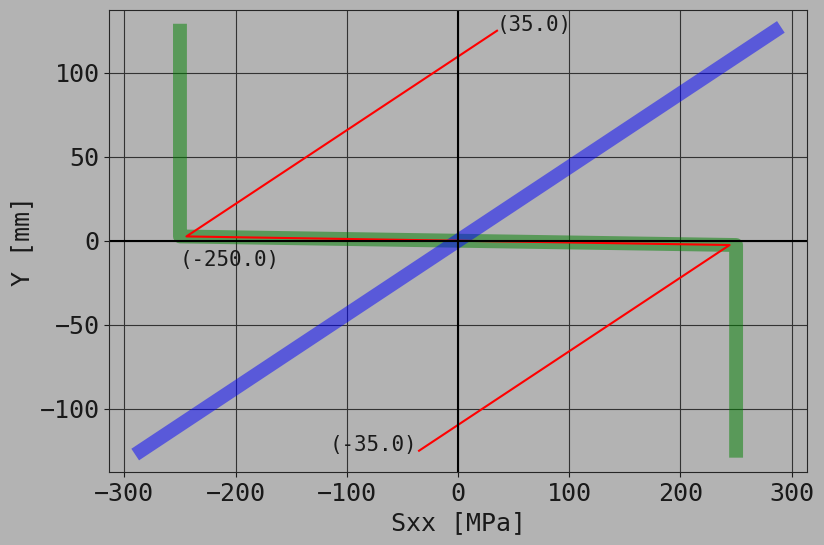

In [11]:
def sreal2plo(j):
    if j >= 0:
        real = - SigC
    else:
        real = SigC
    return  real

def simg2plo(j):
    return Mp/Iz*j

yplo = np.linspace(-S.ht/2,S.ht/2) # unit: mm
sRplo = np.zeros(len(yplo))
for j in range(0,len(yplo)):
    sRplo[j] = sreal2plo(yplo[j])

sIplo = simg2plo(yplo)

#initialize a plot
ax = plt.figure(figsize=(9,6))
plt.plot(sRplo,yplo,'-g',linewidth=10, alpha=0.5)
plt.plot(sIplo,yplo,'-b',linewidth=10, alpha=0.5)
plt.plot(sRplo+sIplo,yplo,'-r')
plt.text(e1_Sr,e1_y,f'({e1_Sr:.1f})', fontsize=15)
plt.text(e2_Sr,e2_y-15,f'({e2_Sr:.1f})', fontsize=15)
plt.text(e3_Sr*3.3,e3_y,f'({e3_Sr:.1f})', fontsize=15)
plt.xlabel("Sxx [MPa]")
plt.ylabel("Y [mm]")
plt.axhline(y=0, color='k')
plt.axvline(x=0, color='k')
plt.grid()
plt.show()

---

Copyright (c) DEMI - FCT NOVA

Interactive computing by <a href="https://jupyter.org/" target="_blank"> <span
style="color:#333399"> Jupyter Notebook </span> </a> &nbsp;|&nbsp;Coded by <a href = "mailto: jmc.xavier@fct.unl.pt">José Xavier</a>

Licensed under  <a href="http://creativecommons.org/licenses/by-sa/4.0/"
target="_blank"> <span style="color:#333399;font-size: 20px"> CC BY-SA 4.0  </span></a>